## Все необходимые импорты

In [1]:
# Импорты на все возможные предметы Юры

# Предобработка
import numpy as np
import pandas as pd

# Визуализация
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Scrapping & Parsing
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm

# Machine Learning
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, accuracy_score, mean_absolute_error

## Базовые понятия

### Введение

<center>
    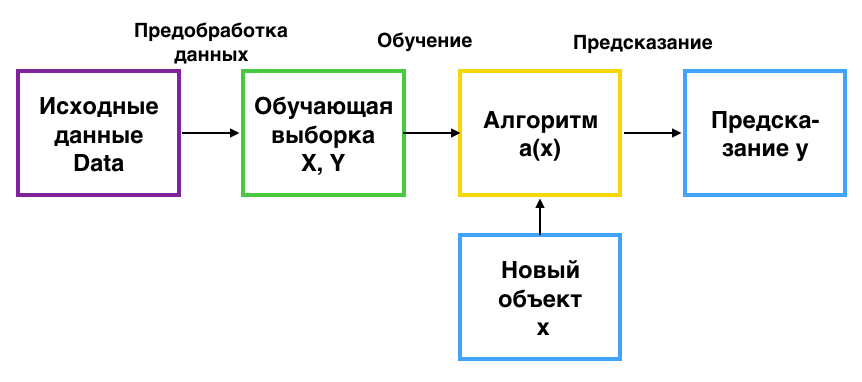
</center>

**Объект** — то, для чего мы строим предсказание.

**Признак** — характеристика, описание объекта.

> **Пример:** объект — квартира №29, признаки — общая площадь, расстояние до метро, этаж и т.д.

Поскольку у объекта много характеристик, математически это вектор-строка или вектор-столбец из чисел:


$$x = (x_1, x_2, ..., x_d)$$


где $d$ — это количество признаков у объекта (разномерность пространства признаков).

**$X$ — матрица объектов-признаков:** таблица, где собраны описания всех объектов (строки) по их характеристикам (столбцы).

**$y$ — целевая переменная:** то конкретное свойство объекта (правильный ответ), которое наш алгоритм должен научиться предсказывать.

**$Y$ — пространство ответов:** столбец, содержащий истинные (правильные) значения целевой переменной для каждого объекта из матрицы $X$.

**Обучающая выборка $(X, Y)$** — это упорядоченный набор данных (комплект из матрицы объектов-признаков $X$ и вектора ответов $Y$), на котором алгоритм учится находить скрытые закономерности.

---

**Алгоритм (модель) $a(x)$** — это функция, которая принимает на вход признаки объекта $x$ и использует текущие параметры (веса), чтобы рассчитать для него предсказание.

**Процесс обучения:**
На этапе обучения алгоритм пропускает через себя признаки объектов из матрицы $X$ и для каждого из них делает прогноз. Затем этот прогноз сравнивается с истинным ответом из вектора $Y$.

**Функционал ошибки (функция потерь / Loss function)** — мера качества работы алгоритма на выборке(чем меньше, тем лучше).

Если алгоритм ошибается, он корректирует свои внутренние параметры (веса). Этот цикл повторяется многократно до тех пор, пока на объектах обучающей выборки модель не начнет выдавать минимально возможную ошибку. 

**Задача обучения** — найти такие веса, с которыми алгоритм сможет точно предсказывать целевую переменную уже для *новых объектов*, которых не было в обучающей выборке.

**Параметры (веса)** алгоритм вычисляет и настраивает автоматически в процессе обучения, анализируя обучающую выборку. В то же время **гиперпараметры** задаются вручную разработчиком еще *до* запуска обучения, так как они определяют сами правила, по которым модель будет учиться.

> **Пример:** В методе $K$-ближайших соседей (KNN) количество соседей $K$ — это **гиперпараметр**, который мы фиксируем заранее. В процессе работы алгоритм не меняет это число, а использует его как жесткое правило для поиска предсказаний.

### Типы задач в машинном обучении

В зависимости от того, какой вид имеет целевая переменная $y$ и что именно должен сделать алгоритм, задачи машинного обучения делятся на несколько основных типов.

**1. Регрессия (Regression)**

Задача, в которой мы предсказываем конкретное вещественное число.

* **Целевая переменная $y$:** непрерывное числовое значение ($y \in \mathbb{R}$).
* **Суть задачи:** настроить алгоритм так, чтобы он возвращал значение, максимально близкое к истинному числу.

> **Пример:** предсказание стоимости квартиры по её характеристикам (площади, этажу, району), прогноз температуры на завтра или курса валют.

---

**2. Классификация (Classification)**

Задача, в которой мы предсказываем, к какой из заранее известных категорий (классов) относится объект.

* **Целевая переменная $y$:** метка класса (дискретное значение).
* **Бинарная классификация:** классов всего два (например, $y \in \{0, 1\}$ или $y \in \{-1, +1\}$).
> **Пример:** является ли транзакция мошеннической (да/нет), болен ли пациент (да/нет).


* **Многоклассовая классификация (Multiclass classification):** классов больше двух, но объект может принадлежать строго к одному из них.
> **Пример:** определение рукописной цифры на картинке (классы от 0 до 9) или классификация марки автомобиля по фотографии.



---

**3. Классификация с пересекающимися классами (Multi-label classification)**

Особый случай классификации, когда объект может обладать сразу несколькими свойствами или относиться к нескольким категориям одновременно.

* **Целевая переменная $y$:** вектор (набор) из $K$ нулей и единиц: $\mathbb{Y} = \{0, 1\}^K$, где $K$ — общее количество возможных классов.
* **Суть задачи:** каждый $i$-й элемент этого вектора-ответа показывает, принадлежит ли объект $i$-му классу (1 — принадлежит, 0 — нет).

> **Пример:** Определение тем для научной статьи. Если возможные темы — это *(математика, биология, экономика)*, то для статьи на стыке биоматематики ответом будет вектор $(1, 1, 0)$.

---

**4. Кластеризация (Clustering)**

Задача обучения *без учителя*, когда у нас есть только матрица признаков $X$, а правильных ответов $Y$ в данных изначально нет.

* **Суть задачи:** алгоритм должен самостоятельно проанализировать признаки объектов, найти сходства и разделить (сгруппировать) все объекты на похожие группы — кластеры.

> **Пример:** сегментация клиентов интернет-магазина по их поведению для настройки таргетированной рекламы (выделение групп «экономные», «шопоголики», «случайные покупатели»).

---

**5. Ранжирование (Ranking)**

Задача, в которой важно не просто угадать число или класс, а правильно расставить объекты по порядку (отсортировать их).

* **Входные данные:** поисковый запрос $q$ и набор доступных документов $d_1, \dots, d_n$.
* **Суть задачи:** отсортировать документы по их *релевантности* (полезности) для данного запроса.
* **Алгоритм $a(q, d)$:** выдает оценку релевантности для каждой пары «запрос-документ». На основе этих оценок строится финальный список, где самые полезные объекты оказываются на первых местах.

> **Пример:** поисковая выдача Яндекса или Google (показывать самые подходящие сайты сверху), а также рекомендательные системы музыкальных и видеосервисов.

---

### Типы признаков

Признаки, из которых состоит вектор объекта, по своей природе и математическому смыслу делятся на четыре основных типа:

* **Вещественные (числовые):** принимают любые числовые значения, над ними можно выполнять любые арифметические операции (например, *возраст*, *площадь квартиры*).
* **Бинарные:** самый простой случай, принимают всего два значения: $0$ или $1$ (например, ответ на вопрос: *«Доход клиента выше среднего?»* или *«Цвет фрукта — зеленый?»*).
* **Категориальные (номинальные):** описывают принадлежность к какому-то неупорядоченному множеству текстовых или числовых меток (например, *город*, *цвет глаз*). Из-за отсутствия математического порядка они весьма трудны в обращении и требуют предварительного кодирования.
* **Порядковые:** похожи на категориальные, но их значения образуют упорядоченное множество, где можно четко сказать, что один вариант больше или главнее другого (например, *воинское звание*, *тип населенного пункта* или *роль в фильме: первого плана, второго плана, массовка*).

### Гипотеза компактности

Если два объекта похожи друг на друга, то ответы на них тоже похожи

## Метод k ближайших соседей(kNN)

### Обучение kNN

Обучение модели: заключается в банальном запоминании всей обучающей выборки $(X, Y)$.

### kNN применение: задача классификации

#### Алгоритм

Дано: новый объект $x$

Применение модели:

* Сортируем объекты обучающей выборки по расстоянию до нового объекта:

$$\rho(x, x_{(1)}) \le \rho(x, x_{(2)}) \le \dots \le \rho(x, x_{(l)})$$


* Выбираем $k$ ближайших объектов: $x_{(1)}, \dots, x_{(k)}$
* Выдаём наиболее популярный среди них класс:

$$a(x) = \arg\max_{y \in \mathbb{Y}} \sum_{i=1}^{k} [y_{(i)} = y]$$

#### Функция потерь для классификации

* Частый выбор — бинарная функция потерь

$L(y, a) = [a \neq y]$


* Функционал ошибки — доля ошибок (error rate)

$Q(a, X) = \frac{1}{\ell} \sum_{i=1}^{\ell} [a(x_i) \neq y_i]$


* Нередко измеряют долю верных ответов (accuracy):

$Q(a, X) = \frac{1}{\ell} \sum_{i=1}^{\ell} [a(x_i) = y_i]$

Заметим, что ```error rate + accuracy = 1```

### Метрики

Метрика — обобщение расстояния на многомерные пространства

Метрика — это функция $\rho$ с двумя аргументами, удовлетворяющая трём требованиям:

* $\rho(x, z) = 0$ тогда и только тогда, когда $x = z$
* $\rho(x, z) = \rho(z, x)$
* $\rho(x, z) \le \rho(x, v) + \rho(v, z)$ — неравенство треугольника





Евклидова метрика

$\rho(x, z) = \sqrt{\sum_{j=1}^{d} (x_j - z_j)^2}$

---

Манхэттенская метрика

$\rho(x, z) = \sum_{j=1}^{d} |x_j - z_j|$

---


Обобщение

$\rho(x, z) = \sqrt[p]{\sum_{j=1}^{d} |x_j - z_j|^p}$

* Метрика Минковского
* Можно подбирать $p$ под конкретную задачу

---

Считающая метрика

* Простейшая метрика: подсчёт различий

$\rho(x, z) = \sum_{j=1}^{d} [x_j \neq z_j]$

### Обобщающая способность (Generalization) и переобучение (Overfitting)

Главная цель машинного обучения — сделать так, чтобы алгоритм хорошо работал не только на тех примерах, которые мы ему показали во время тренировки, но и на абсолютно новых, незнакомых данных. Эту способность называют **обобщающей способностью (generalization)**. Если же алгоритм вместо поиска скрытых закономерностей просто зазубривает тренировочный набор данных вместе со всем случайным шумом, он теряет эту способность — такое явление называется **переобучением (overfitting)**. На обучающей выборке переобученная модель показывает идеальные результаты, но на любых новых данных она начинает сильно ошибаться.

Чтобы понять разницу между плохим и хорошим обучением, можно провести идеальную аналогию с тем, как студент готовится к экзамену:

| Стратегия «Зубрёжка» | Стратегия «Понимание» |
| :---: | :---: |
| Заучить все примеры с занятий наизусть | Разобраться в предмете и усвоить алгоритмы решения задач |
|  **Переобучение (Overfitting)** | **Обобщение (Generalization)** |
| Хорошее качество на обучении | Хорошее качество на обучении |
| Низкое качество на новых данных | Хорошее качество на новых данных |

### Оценка качества модели и подбор гиперпараметров

Чтобы настроить модель и убедиться, что она действительно способна решать поставленную задачу на практике, нам нужно решить две проблемы:

1. **Оценить качество работы:** понять, насколько хорошо алгоритм будет справляться с абсолютно новыми объектами.
2. **Подобрать гиперпараметры:** найти такие настройки алгоритма (например, число соседей $K$ в kNN), при которых модель покажет наилучший результат и не переобучится.

#### 1. Отложенная выборка (Hold-out method)

Самый простой и популярный способ оценить модель — разделить исходные данные на отдельные независимые части. Обычно весь датасет бьется на две или три выборки:

* **Обучающая (Train set):** часть данных (например, 70%), на которой алгоритм настраивает свои параметры/веса.
* **Валидационная (Validation set):** отложенный кусочек данных, на котором разработчик тестирует модель с разными гиперпараметрами, чтобы выбрать лучший вариант.
* **Тестовая (Test set):** финальный кусок данных, который модель вообще никогда не видела. Нужен для итогового, самого честного замера точности.

> На самом деле, валидационную выборку используют не всегда. Когда используют — стараются брать того же размера, что и тестовую

* слишком большое обучение - тестовая выборка нерепрезентативна
* слишком большой тест - модель не сможет обучиться
* обычно 70/30, 80/20

<center>
    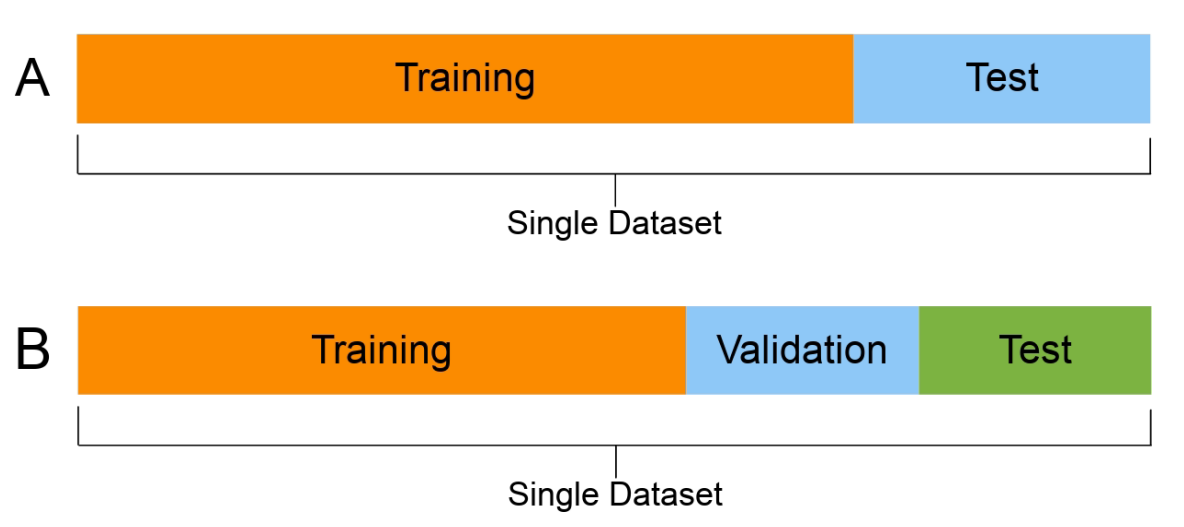
</center>

#### 2. Кросс-валидация (Cross-Validation / K-fold)

Этот подход решает проблему случайности при разделении данных. Мы не просто один раз откладываем кусок данных в сторону, а заставляем все объекты побывать и в роли обучающих, и в роли проверочных.

**Как это работает:**

* Мы берем фиксированный гиперпараметр (например, задаем число соседей $K = 3$).
* Весь датасет делится на $n$ равных частей.
* Из полученных $n$ частей, $n - 1$ часть используются для обучения и одна — для тестирования (валидации)
* Процесс повторяется $n$ раз. Каждый раз для тестирования выбирается новая, еще не использованная часть данных
* Результаты тестирования усредняются

Мы повторяем этот полный цикл для разных гиперпараметров и в итоге выбираем тот, у которого средняя ошибка по всем частям оказалась минимальной

**Плюсы:**
* Погрешность оценки уменьшается, т.к. используется весь набор
* Качество модели улучшается(при увеличении $n$) и можно подобрать оптимальные
гиперпараметры алгоритма

**Минусы:**
* Обучение производится $n$ раз. Для некоторых моделей это может быть
очень долго


<center>
    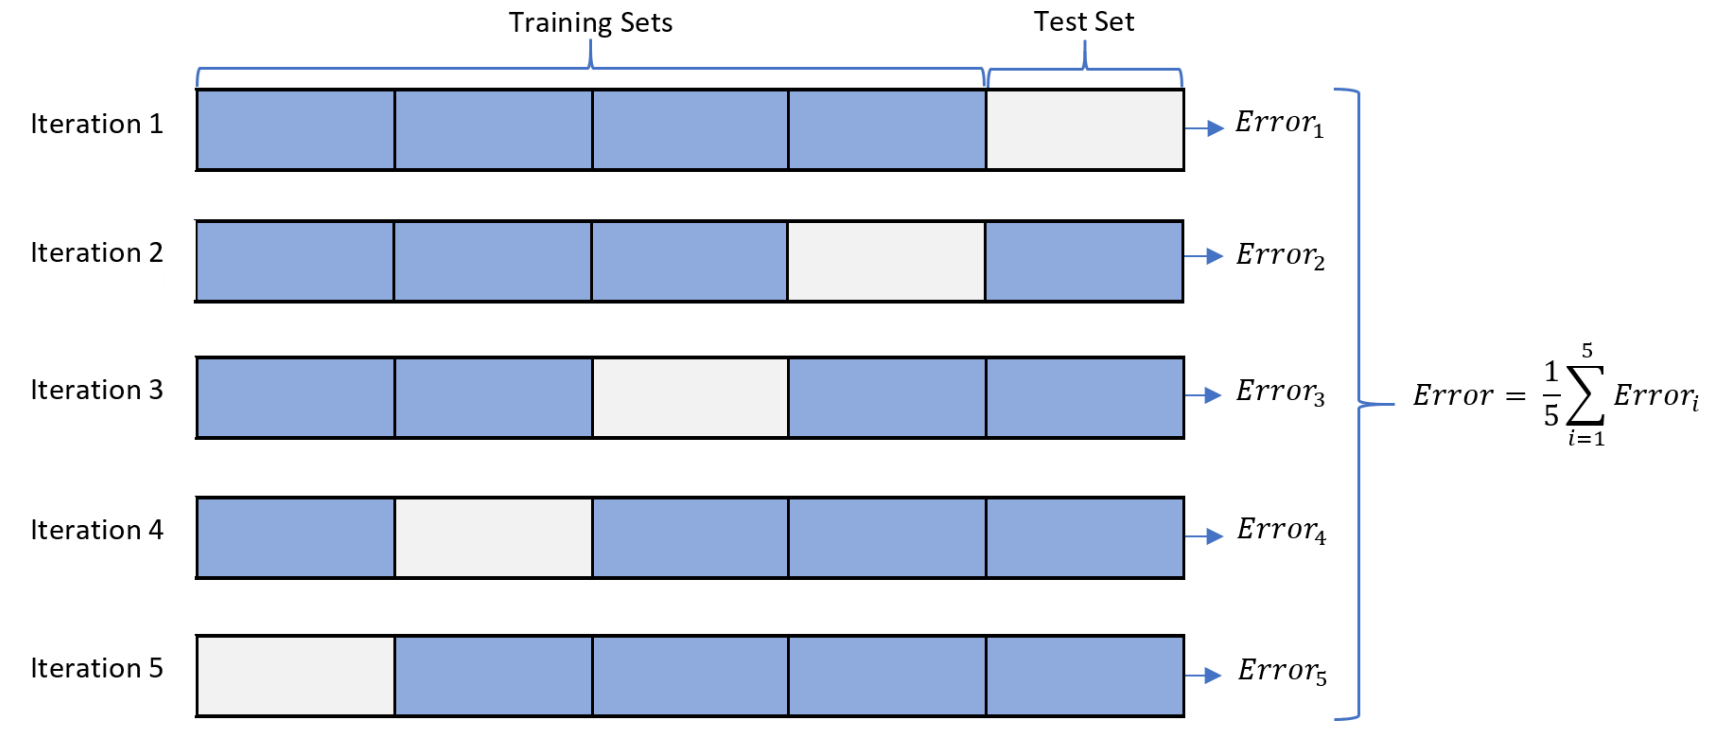
</center>

### Взвешенный kNN

Давайте рассмотрим пример. Нужно определить класс серого объекта. Если взять $k = 2$, то проблем нет: серый объект определится в класс синих. Если же взять $k = 5$, то в выборку из 5 соседей попадут 2 синих и 3 оранжевых объекта. Казалось бы, серый кружок должен стать оранжевым, но интуитивно мы понимаем, что те 3 оранжевых кружка слишком далеко, поэтому хочется сказать, что кружок все равно синий.

Таким образом, мы хотим, чтобы наш текущий kNN учитывал расстояние до соседей в голосовании за класс

<center>
    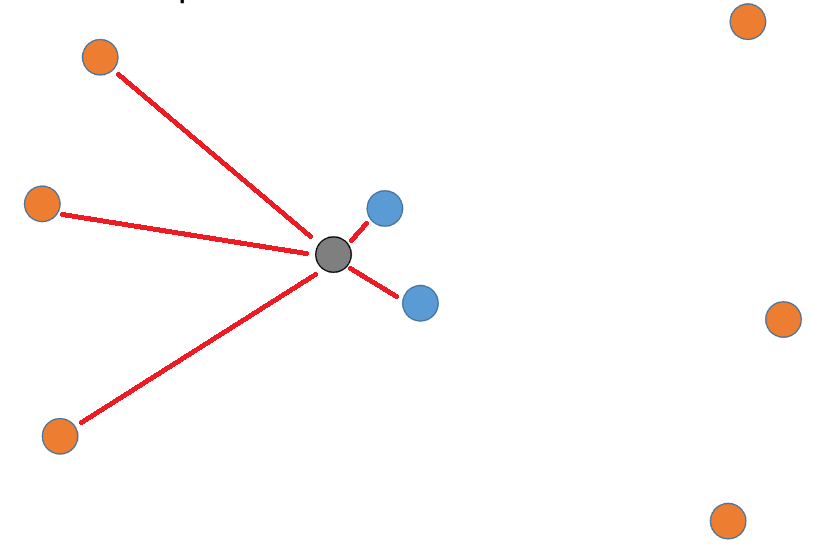
</center>

Формула предсказания для взвешенного kNN выглядит следующим образом:$$a(x) = \arg \max_{y \in \mathbb{Y}} \sum_{i=1}^{k} w_i [y_{(i)} = y]$$Где $w_i$ — вес $i$-го соседа

**Варианты назначения весов от порядка соседа**

Простейшие модификации взвешенного kNN определяют вес объекта на основе его индекса (порядкового номера) после сортировки по близости:

* **Линейно убывающие веса:**

$$w_i = \frac{k + 1 - i}{k}$$



Здесь первый (самый близкий) сосед получает максимальный вес $1$, а каждый следующий вносит всё меньший вклад.
* **Экспоненциально убывающие веса:**

$$w_i = q^i \quad (0 < q < 1)$$



Вес соседа уменьшается в геометрической прогрессии с ростом его дистанционного номера.

**Главный минус этих вариантов:** Они учитывают только порядковый номер соседа после сортировки, но абсолютно игнорируют реальные расстояния между объектами. Например, второй и третий сосед могут находиться на принципиально разном удалении от новой точки, но их веса всё равно будут рассчитываться по стандартному шагу.

---

* **Метод Парзеновского окна (Parzen Window)**

Чтобы учесть реальное геометрическое расстояние до объектов, используется модификация с применением специальных функций ядра. В этом случае вес соседа напрямую зависит от расстояния $\rho(x, x_{(i)})$:

$$w_i = K\left( \frac{\rho(x, x_{(i)})}{h} \right)$$

* $K(z)$ — **ядро**. Это невозрастающая функция, которая преобразует расстояние в вес. Чем аргумент ближе к нулю, тем больше ядро
* $h$ — **ширина окна**. Это гиперпараметр, который определяет масштаб изменения расстояний(т.е. определяет то, насколько мы чувствительны к изменению расстояния до объектов)

<center>
    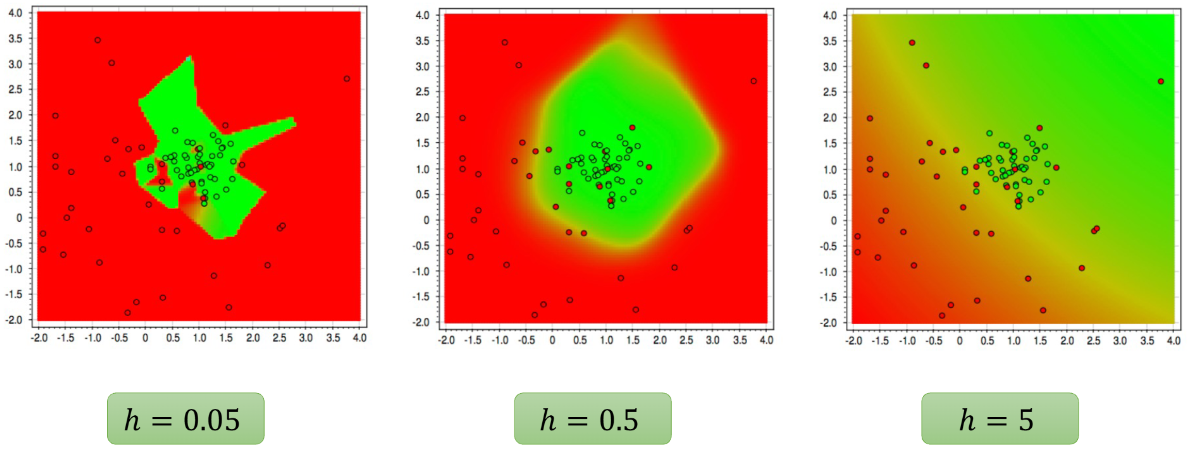
</center>

### kNN для регрессии

#### Алгоритм

Дано: новый объект $x$

Применение модели:

* Сортируем объекты обучающей выборки по расстоянию до нового объекта:

$$\rho(x, x_{(1)}) \le \rho(x, x_{(2)}) \le \dots \le \rho(x, x_{(l)})$$

* Выбираем $k$ ближайших объектов: $x_{(1)}, \dots, x_{(k)}$
* Усредняем ответы:

$$a(x) = \frac{1}{k} \sum_{i=1}^{k} y_{(i)}$$

Есть вариация с весами, но я не буду её здесь упоминать(см. лекцию 3)

#### Функции потерь и функционалы ошибки для регрессии

* Частый выбор — **квадратичная функция потерь**

$$L(y, a) = (a - y)^2$$

* Функционал ошибки — **среднеквадратичная ошибка(mean squared error, MSE)**

$$Q(a, X) = \frac{1}{l} \sum_{i=1}^{l} (a(x_i) - y_i)^2$$

---

* Еще один вариант — **Средняя абсолютная ошибка (Mean Absolute Error, MAE)**

$$Q(a, X) = \frac{1}{l} \sum_{i=1}^{l} |a(x_i) - y_i|$$

## Линейная регрессия

### Линейная регрессия — это

**Простейший случай: один признак**
* Модель: $a(x) = w_{1}x + w_0$
* Два параметра: $w_1$ и $w_0$
* Геометрический смысл: прямая

---

**Два признака**
* Модель: $a(x) = w_0 + w_{1}x_{1} + w_{2}x_{2}$
* Три параметра: $w_0$, $w_{1}$ и $w_{2}$
* Геометрический смысл: плоскость

---

**Общий случай: d признаков**
* Модель: $a(x) = w_0 + w_{1}x_{1} + ... + w_{d}x_{d}$
* Количество параметров: $d + 1$
* $w_0$ нужен для общности: если все признаки нулевые, то без $w_0$ прогноз будет железобетонно равным нулю, т.е. с помощью $w_0$ мы регулируем случай, когда все признаки равны нулю

Запишем через скалярное произведение: $a(x) = w_0 + w_{1}x_{1} + ... + w_{d}x_{d} = w_0 + \langle w, x \rangle$

Будем считать, что есть признак, всегда равный единице: $a(x) = w_{1}x_{1} + ... + w_{d}x_{d} = \langle w, x \rangle$

### Применимость линейной регрессии

* Нет гарантий, что целевая переменная именно так зависит от признаков
* Надо формировать признаки так, чтобы модель подходила

**Кейс: предсказание стоимости квартиры**

* Признаки: площадь, район, расстояние до метро
* Целевая переменная: рыночная стоимость квартиры
* Линейная модель: $a(x) = w_0 + w_1 * ($площадь$) + w_2 * ($район$) + w_3 * ($расстояние до метро$)$

Если с площадью все понятно, то что делать с другими признаками - непонятно

#### Кодирование категориальных признаков

Одним из методов кодирования категориальных признаков является One-Hot Encoding

**One-Hot Encoding** — это метод преобразования категориальных признаков в числовые векторы, при котором для каждого уникального значения категории создается отдельная новая колонка, заполненная нулями и единицами. При этом для каждого конкретного объекта единица ставится строго в одной новой колонке, соответствующей его текущему значению, а во всех остальных — нули



In [2]:
data = pd.DataFrame({'Район': ['ЦАО', 'ЮАО', 'ЦАО', 'САО', 'ЮАО']})

print("Исходные данные:")
display(data)

# Параметр dtype='int' нужен, чтобы в таблицу записались 0 и 1 (по умолчанию True/False)
data_encoded = pd.get_dummies(data, columns=['Район'], dtype='int')

print("Данные после One-Hot Encoding:")
display(data_encoded)

Исходные данные:


,Район
0,ЦАО
1,ЮАО
2,ЦАО
3,САО
4,ЮАО


Данные после One-Hot Encoding:


,Район_САО,Район_ЦАО,Район_ЮАО
0,0,1,0
1,0,0,1
2,0,1,0
3,1,0,0
4,0,0,1


**Недостаток:** увеличивает размеры выборки

#### Бинаризация признаков

Если мы попытаемся применить обычную линейную регрессию напрямую к непрерывному признаку, модель сможет провести только одну прямую линию. Прямая линия абсолютно не описывает реальную сложную зависимость в данных. Модель будет сильно ошибаться.

<center>
    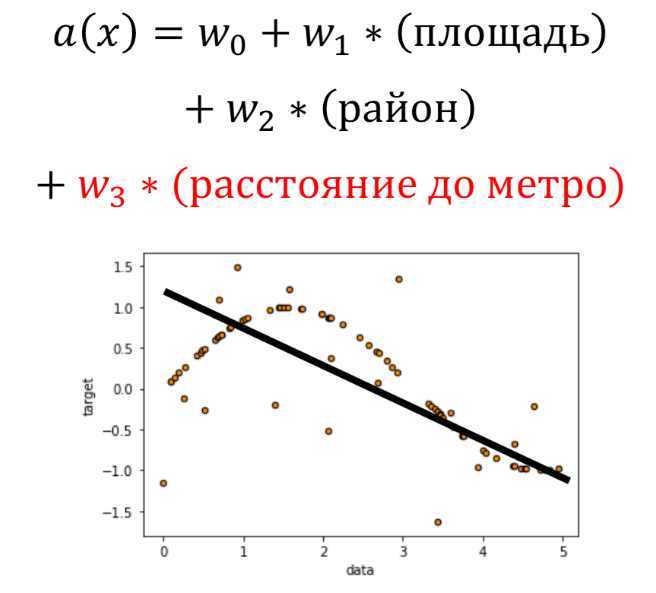
</center>

Чтобы исправить это, мы можем применить **бинаризацию** к непрерывному признаку.

**Бинаризация вещественного признака** — это метод преобразования одного непрерывного числового признака в один или несколько бинарных признаков путем разбиения шкалы его значений по пороговым интервалам (bins). Такая модель описывает сложную зависимость гораздо точнее

<center>
    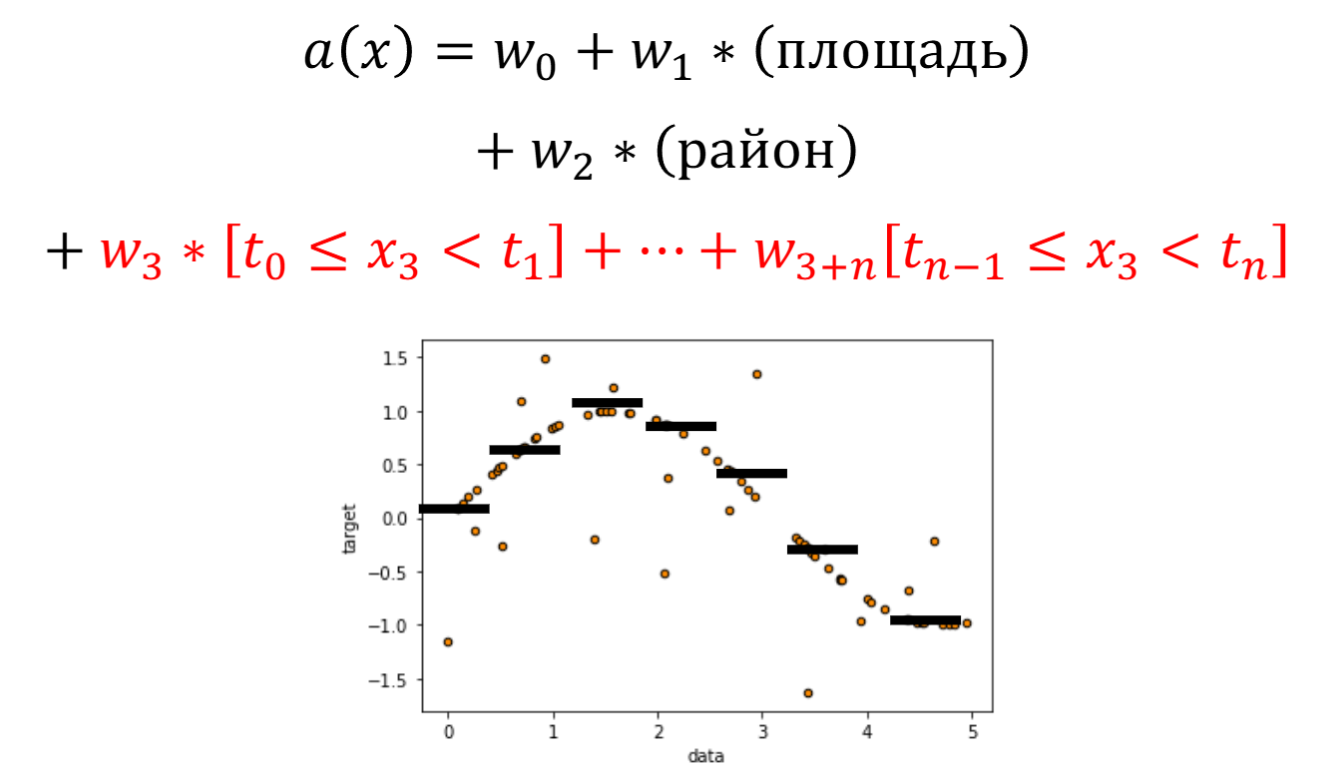
</center>

#### Генерация полиномиальных признаков

Сама по себе линейная регрессия умеет строить только прямые линии, плоскости и другие линейные подпространства. Однако мы можем обмануть систему: если мы вручную добавим в датасет новые признаки, которые являются математическими комбинациями старых (возведем в квадрат, перемножим между собой), то обычная линейная модель сможет описывать сложные криволинейные зависимости.

Такой подход называется **генерацией полиномиальных признаков (Polynomial Features)**:

$$a(x) = w_0 + w_1 \cdot (\text{площадь}) + w_2 \cdot (\text{этаж}) + w_3 \cdot (\text{расстояние до метро})$$

$$+ w_4 \cdot (\text{площадь})^2 + w_5 \cdot (\text{этаж})^2 + w_6 \cdot (\text{расстояние до метро})^2$$

$$+ w_7 \cdot (\text{площадь}) \cdot (\text{этаж}) + \dots$$

Почему модель всё еще называется «линейной»? Несмотря на то, что график предсказания на бумаге станет изогнутым и нелинейным, сама модель с точки зрения математики остается линейной. Она линейна относительно своих весов (параметров $w$).

Помимо возведения в квадрат и перемножения признаков между собой, существуют и другие математические нелинейности, которые можно вычислять для вещественных столбцов перед подачей в линейную модель. Выбор конкретной функции зависит от физического смысла данных:

* $\log(\text{площадь})$
* $\sqrt{\text{площадь}}$
* $\sin(\text{площадь})$

### Линейная регресссия в векторном виде

Когда мы работаем с одним объектом, предсказание линейной модели — это просто скалярное произведение вектора весов на вектор признаков:

$$a(x) = \langle w, x \rangle = w_1x_1 + \dots + w_dx_d$$

Однако на практике в обучающей выборке содержатся тысячи объектов. Считать предсказания для каждого из них по отдельности через циклы в Python — очень медленно. Чтобы ускорить вычисления, используют **матричное умножение**.

Чтобы получить вектор предсказаний для всех $\ell$ объектов выборки, мы умножаем **матрицу «объект-признак»** $X$ на **вектор-столбец весов** $w$.

$$
\begin{pmatrix} 
x_{11} & x_{12} & \dots & x_{1d} \\ 
x_{21} & x_{22} & \dots & x_{2d} \\ 
\vdots & \vdots & \ddots & \vdots \\ 
x_{\ell1} & x_{\ell2} & \dots & x_{\ell d} 
\end{pmatrix}
\begin{pmatrix} 
w_1 \\ 
w_2 \\ 
\vdots \\ 
w_d 
\end{pmatrix} 
=
\begin{pmatrix} 
\sum_{i=1}^{d} w_i x_{1i} \\ 
\sum_{i=1}^{d} w_i x_{2i} \\ 
\vdots \\ 
\sum_{i=1}^{d} w_i x_{\ell i} 
\end{pmatrix}
$$

В сокращенной векторно-матричной форме эта операция записывается предельно просто:

$$a(X) = Xw$$

---

**Матричная запись функционала ошибки MSE** $$\frac{1}{\ell} \sum_{i=1}^{\ell} (\langle w, x_i \rangle - y_i)^2 = \frac{1}{\ell} \|Xw - y\|^2 \to \min_{w}$$

В Python считается следующим образом:```np.square(X.dot(w) - y).mean()```

Вертикальные двойные черты **$\| \dots \|$** вобозначают **евклидову норму вектора** (её еще называют $L_2$-нормой). Если говорить простыми словами: норма — это длина вектора в многомерном пространстве, посчитанная по теореме Пифагора

1. **$Xw - y$** — это вектор отклонений (ошибок). Внутри него лежат разности $(a(x_1) - y_1), (a(x_2) - y_2)$ и так далее для каждого объекта.

2. **$\|Xw - y\|$** — длина этого вектора ошибок. Чтобы её найти, нужно возвести каждую ошибку в квадрат, сложить их и взять корень: $\sqrt{\sum (a(x_i) - y_i)^2}$.


3. **$\|Xw - y\|^2$** — мы возводим норму в квадрат, чтобы избавиться от квадратного корня.

### Обучение линейной регрессии

Вспомним из курса математического анализа, что такое градиент:

$$\nabla f(x) = \left( \frac{\partial f}{\partial x_1}, \dots, \frac{\partial f}{\partial x_d} \right)$$

Геометрический смысл: градиент всегда показывает направление наибыстрейшего роста значения функции, а его длина (модуль) равна скорости этого роста

<center>
    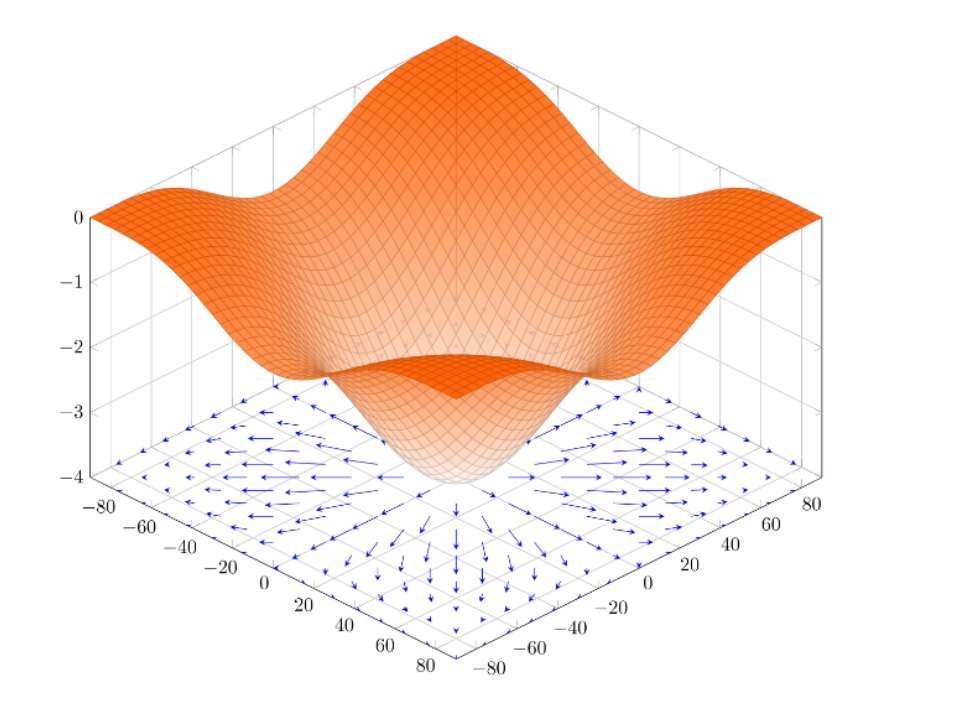
</center>

* Если точка $x_0$ - экстремум и в ней существует производная, то $$\nabla f(x) = 0$$
* Если функция выпуклая, то экстремум один
* MSE для линейной регрессии - выпуклая (при некоторых условиях)

Можно посчитать градиент MSE:

$$
\nabla \frac{1}{\ell} \|Xw - y\|^2 = \frac{2}{\ell} X^T (Xw - y)
$$

Приравниваем к нулю и решаем систему линейных уравнений:

$$w = (X^T X)^{-1} X^T y$$

### Переобучение и регуляризация линейных моделей

* Существует эмпирическое наблюдение о том, что большие веса в модели — симптом переобучения

Когда мы добавляем в модель полиномиальные признаки (квадраты, попарные произведения) или другие сложные нелинейные трансформации, размерность пространства признаков стремительно растет.

В таких условиях обычная линейная регрессия начинает переобучаться. Это выражается в том, что модель пытается идеально подстроиться под каждую точку обучающей выборки, из-за чего её коэффициенты (веса $w$) «взрываются» и уходят в огромные положительные и отрицательные значения.
> Пример: $a(x) = 698x - 41714$

> Изменение веса на $0.01$ кг приведет к изменению роста на $7$ см

<center>
    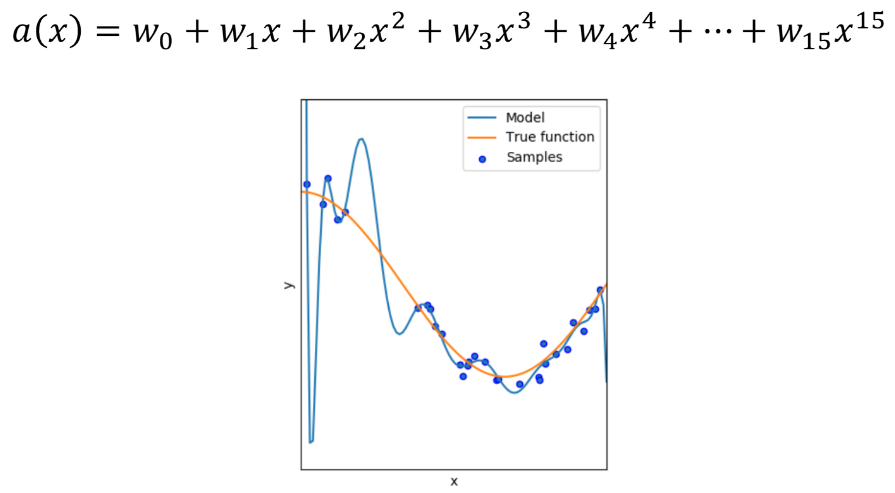
</center>

Чтобы этого избежать, применяется **регуляризация** — метод штрафования избыточной сложности модели.

#### Регулязация

Основная идея регуляризации проста: будем штрафовать модель за слишком большие веса.

Для этого мы модифицируем наш стандартный функционал ошибки MSE. Мы добавляем к нему специальное слагаемое — **регуляризатор (штраф)**, который зависит от величины весов модели.

В качестве штрафа чаще всего используют квадрат евклидовой нормы вектора весов (также известный как $L_2$-регуляризатор):

$$\|w\|^2 = \sum_{j=1}^{d} w_j^2$$

Линейная регрессия, в которой функция потерь MSE модифицирована добавлением штрафа за большие значения весов называется *гребневой регрессией(ridge regression)*

$$\frac{1}{\ell} \sum_{i=1}^{\ell} (\langle w, x_i \rangle - y_i)^2 + \lambda \|w\|^2 \to \min_{w}$$
$\lambda$ — коэффициент регуляризации (гиперпараметр). Он управляет силой штрафа.

Решение задачи минимизации: $$w = (X^T X + \lambda I)^{-1} X^T y$$

---

Альтернативным способом борьбы с переобучением является **Лассо-регрессия** (LASSO — Least Absolute Shrinkage and Selection Operator).

В отличие от гребневой регрессии, Лассо-регрессия использует модуль($L_1$-норма):

$$\frac{1}{\ell} \sum_{i=1}^{\ell} (\langle w, x_i \rangle - y_i)^2 + \lambda \sum_{j=1}^{d} |w_j| \to \min_{w}$$

* LASSO обладает свойством занулять некоторые веса в процессе оптимизации. Это приводит к отбору неважных или сильно скоррелированных признаков.

### Поиск гиперпараметров

Для поиска оптимального коэффициента регуляризации существует множество различных подходов. Наиболее популярными являются кросс-валидация, с которой мы уже знакомы, и метод Grid Search.

**Grid Search (поиск по сетке)** — это метод автоматического подбора гиперпараметров, при котором алгоритм последовательно перебирает все возможные комбинации заданных значений из заранее определенного списка (сетки).

Стоит отметить, что для таких параметров, как коэффициент регуляризации, чаще всего задают логарифмическую сетку (например, $[0.001, 0.01, 0.1, 1, 10, 100]$). Это необходимо потому, что оптимальное значение штрафа может отличаться на порядки, и обычный линейный шаг не позволит эффективно нащупать нужный масштаб регуляризации.

### Масштабирование признаков

Когда мы анализируем обычную линейную регрессию, может возникнуть соблазн сделать вывод: *«Чем больше абсолютное значение веса $w_j$, тем важнее признак для итогового предсказания»*. Однако это утверждение верно только в том случае, если все признаки масштабированы.

Представим модель, предсказывающую стоимость квартиры:

$$a(x) = 100\,000 \cdot (\text{площадь в кв.м.}) + 500\,000 \cdot (\text{число магазинов}) + 100 \cdot (\text{средний доход жильцов})$$

Здесь вес при доходе жильцов ($100$) кажется очень маленьким по сравнению с весом площади ($100\,000$). Но сам доход измеряется в десятках или сотнях тысяч рублей, в то время как площадь — в десятках единиц. Из-за этого масштабы весов сильно перекошены, и мы не можем сравнивать их значимость напрямую.

**Стандартизация признаков (StandardScaler)**

Чтобы регуляризация работала корректно и честно штрафовала каждый признак, их необходимо привести к единому масштабу. Чаще всего для этого применяется стандартизация.

Из каждого значения признака вычитается его среднее значение по выборке ($\mu_j$), и результат делится на стандартное отклонение ($\sigma_j$):

$$x_{ij} := \frac{x_{ij} - \mu_j}{\sigma_j}$$

После такой трансформации:

* Все новые признаки будут иметь среднее значение **$0$**.
* Все признаки будут иметь дисперсию (и стандартное отклонение) **$1$**.

### Альтернативные функции потерь

**Коэффициент детерминации $R^2$**

Поскольку значение ошибки $MSE$ измеряется в квадратных единицах целевой переменной, его трудно интерпретировать «с ходу». Чтобы оценивать качество регрессии в относительных единицах, используют метрику $R^2$ (коэффициент детерминации).

Идея заключается в сравнении нашей модели с константным предсказанием (базовым уровнем, когда для любого объекта мы просто предсказываем среднее значение $\bar{y}$ по выборке):

$$R^2(a, X, Y) = 1 - \frac{\sum_{i=1}^{\ell}(a(x_i) - y_i)^2}{\sum_{i=1}^{\ell}(y_i - \bar{y})^2} = 1 - \frac{\text{MSE модели}}{\text{MSE константы}}$$

* **$R^2 = 1$:** Идеальная модель, ошибок нет вообще ($MSE = 0$). На практике — это переобучение.
* **$0 < R^2 < 1$:** Модель работает лучше базового предсказания средним.
* **$R^2 \le 0$:** Линейная регрессия предсказывает на уровне константы или даже хуже неё. Модель бесполезна.

---

Помимо $MSE$, существуют другие метрики, которые по-разному реагируют на ошибки и выбросы в данных.

**1. MAE (Mean Absolute Error) — Средняя абсолютная ошибка**

$$\text{MAE}(a, X) = \frac{1}{\ell} \sum_{i=1}^{\ell} |a(x_i) - y_i|$$

* Она устойчива к выбросам. Если в данных есть аномальный объект с гигантской ошибкой, MAE не будет ломать всю модель ради него.
* Модуль не дифференцируем в нуле, что усложняет оптимизацию.

**2. Huber Loss (Функция потерь Хубера)**

Компромисс между MSE и MAE. Если ошибка маленькая — работает как MSE, если большая (выброс) — переключается на MAE.

$$L_{\delta}(y, a(x)) = 
\begin{cases} 
\frac{1}{2}(y - a(x))^2 & \text{при } |y - a(x)| \le \delta \\
\delta(|y - a(x)| - \frac{1}{2}\delta) & \text{при } |y - a(x)| > \delta 
\end{cases}$$

* Дифференцируема во всех точках (включая ноль) и при этом устойчива к выбросам.
* Появляется ручной гиперпараметр $\delta$, который нужно подбирать.

**3. Log-Cosh Loss (Логарифм гиперболического косинуса)**

Гладкий аналог функции Хубера, работающий «из коробки».

$$L(y, f(x)) = \sum_{i=1}^{\ell} \ln(\cosh(f(x_i) - y_i))$$

* Для маленьких ошибок ведет себя как $\frac{x^2}{2}$ (MSE), для больших — как $|x| - \ln(2)$ (MAE).
* **Плюсы:** Устойчива к выбросам, дважды дифференцируема везде (что круто для вычисления градиентов).

**4. Quantile Loss (Квантильная ошибка)**

Используется для прогнозирования конкретного квантиля распределения (а не среднего значения).

$$L_q(y, f(x)) = \sum_{i=1}^{\ell} \rho_q(y_i - f(x_i)), \quad \text{где } \rho_q(z) = \begin{cases} qz, & z > 0 \\ (q-1)z, & z \le 0 \end{cases}$$

* Штраф за ошибку становится несимметричным. Модель штрафуется сильнее за недопрогноз, если параметр $q$ высокий, и за перепрогноз, если $q$ низкий.

## Практика по kNN и Линейной регрессии

### kNN

Загрузим датасет и удалим пропуски

In [9]:
df_penguins = sns.load_dataset("penguins").dropna()
df_penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Закодируем категориальные признаки

In [10]:
le = LabelEncoder()
df_penguins['species_encoded'] = le.fit_transform(df_penguins['species'])
df_penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_encoded
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,0
...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,2
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,2
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,2
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,2


Используя функцию ```train_test_split()```, разделим выборку на тренировочную и тестовую
> Параметр **test_size** определяет долю тестовой выборки

> Параметр **stratify=Y** отвечает за стратификацию, стратификация важна, так как благодаря ней мы можем быть уверены в том, что соотношение классов в обучающей и тестовой выборке будут одинаковы и, что модель обучится нормально

> Параметр **random_state=16042006** фиксирует сид для воспроизводимости результатов  

In [11]:
X = df_penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = df_penguins['species_encoded']

# Разбиваем на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=16042006, stratify=y)

Масштабируем признаки

In [12]:
scaler_knn = StandardScaler()
X_train_scaled = scaler_knn.fit_transform(X_train)
X_test_scaled = scaler_knn.transform(X_test)

Обучим модель и определим какой $k$ самый лучший

In [13]:
ks = [1, 3, 5, 7, 9, 15, 21, 35, 50]
best_k = None
best_test_acc = 0

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    
    train_preds = knn.predict(X_train_scaled)
    test_preds = knn.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    
    print(f"k = {k} | Accuracy на train: {train_acc:.4f} | Accuracy на test: {test_acc:.4f}")
    
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_k = k

print(f"\n>>> Лучшее количество соседей: k = {best_k} (Accuracy на тесте = {best_test_acc:.4f})\n")

k = 1 | Accuracy на train: 1.0000 | Accuracy на test: 0.9900
k = 3 | Accuracy на train: 1.0000 | Accuracy на test: 1.0000
k = 5 | Accuracy на train: 0.9914 | Accuracy на test: 0.9900
k = 7 | Accuracy на train: 0.9828 | Accuracy на test: 1.0000
k = 9 | Accuracy на train: 0.9828 | Accuracy на test: 0.9900
k = 15 | Accuracy на train: 0.9828 | Accuracy на test: 0.9800
k = 21 | Accuracy на train: 0.9785 | Accuracy на test: 0.9800
k = 35 | Accuracy на train: 0.9785 | Accuracy на test: 0.9700
k = 50 | Accuracy на train: 0.9742 | Accuracy на test: 0.9500

>>> Лучшее количество соседей: k = 3 (Accuracy на тесте = 1.0000)



### Линейная регрессия

In [1]:
# Потом будет

## Градиентный спуск

### Идея алгоритма

Для решения проблемы вычислительной сложности аналитического решения (связанной с необходимостью обращения матрицы $(X^T X)^{-1}$ для больших датасетов) используется градиентный спуск.

Главное свойство градиента заключается в том, что он всегда указывает в сторону наибыстрейшего роста значения функции, а его длина (модуль) равна скорости этого роста в данной точке.

Поскольку наша задача в машинном обучении — это минимизация ошибки, нам нужно двигаться в противоположную от роста сторону. Направление, обратное градиенту, называется **антиградиентом** ($-\nabla Q$). Оно гарантирует направление наибыстрейшего убывания функции.

**Алгоритм:**

* Стартуем из случайной точки
 
> Перед стартом оптимизации необходимо задать вектор весов нулевого шага $w^0$. Поскольку мы еще ничего не знаем об оптимальном решении, веса инициализируются случайными числами — например, берутся из стандартного нормального распределения.
* Сдвигаемся по антиградиенту

> На каждом следующем шаге мы обновляем вектор весов, сдвигаясь против направления градиента функции потерь. Уравнение выглядит следующим образом:
>
>$$w^t = w^{t-1} - \eta \nabla Q(w^{t-1})$$
>
  > $w^t$ — новая (обновленная) точка в пространстве весов.
  >
  > $w^{t-1}$ — точка, полученная на предыдущем шаге алгоритма.
  >
  > $\nabla Q(w^{t-1})$ — градиент функции потерь, вычисленный в предыдущей точке. Он указывает направление наибыстрейшего роста ошибки, а знак «минус» перед ним разворачивает нас в сторону спада.
  >
  > $\eta$ — контролирует **размер шага** (learning rate / темп обучения). Этот гиперпараметр определяет, насколько сильно мы доверяем направлению антиградиента на текущей итерации.
* Повторяем, пока не окажемся в точке минимума

> Этот процесс вычисления градиента и обновления весов повторяется циклически. Мы крутим цикл до тех пор, пока алгоритм не **сойдется** — то есть пока мы не окажемся в точке минимума, где веса перестают существенно изменяться от шага к шагу.
> 
> * Останавливаем процесс, если
> $$\|w^t - w^{t-1}\| < \varepsilon$$
> * Другой вариант:
> $$\|\nabla Q(w^t)\| < \varepsilon$$
> * Или когда ошибка на отложенной выборке перестает уменьшается

### Линейная регрессия



$$Q(w) = \frac{1}{\ell} \sum_{i=1}^{\ell} (\langle w, x_i \rangle - y_i)^2$$

* $\frac{\partial Q}{\partial w_1} = \frac{2}{\ell} \sum_{i=1}^{\ell} x_{i1} (\langle w, x_i \rangle - y_i)$

* ...
* $\frac{\partial Q}{\partial w_d} = \frac{2}{\ell} \sum_{i=1}^{\ell} x_{id} (\langle w, x_i \rangle - y_i)$


* $\nabla Q(w) = \frac{2}{\ell} X^T (Xw - y)$